NAME : VIKAS MALVIYA

SCH. NO. : 25215011109

SUBJECT : LAB 01

TITLE: HAR activity on WISDM dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout


In [ ]:
df=pd.read_csv('/content/time_series_data_human_activities.csv')


In [ ]:
df.head()

,user,activity,timestamp,x-axis,y-axis,z-axis
0,1,Walking,4991922345000,0.69,10.80,-2.03
1,1,Walking,4991972333000,6.85,7.44,-0.50
2,1,Walking,4992022351000,0.93,5.63,-0.50
3,1,Walking,4992072339000,-2.11,5.01,-0.69
4,1,Walking,4992122358000,-4.59,4.29,-1.95


In [ ]:
df.shape

(1073623, 6)

In [ ]:
print(df['activity'].value_counts())

activity
Walking       417901
Jogging       324600
Upstairs      122598
Downstairs    100192
Sitting        59939
Standing       48393
Name: count, dtype: int64


In [ ]:
le = LabelEncoder()
df['activity_encoded'] = le.fit_transform(df['activity'])

print("Label Mapping:")
for i, label in enumerate(le.classes_):
    print(label, "->", i)


Label Mapping:
Downstairs -> 0
Jogging -> 1
Sitting -> 2
Standing -> 3
Upstairs -> 4
Walking -> 5


In [ ]:
def sliding_window(data, window_size=128, step_size=64):
    X, y = [], []

    for i in range(0, len(data) - window_size, step_size):
        window = data.iloc[i:i+window_size]
        X.append(window[['x-axis', 'y-axis', 'z-axis']].values)
        y.append(window['activity_encoded'].mode()[0])

    return np.array(X), np.array(y)

X, y = sliding_window(df)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (16774, 128, 3)
y shape: (16774,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1,3)).reshape(X_train.shape)
X_test  = scaler.transform(X_test.reshape(-1,3)).reshape(X_test.shape)


In [ ]:
model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(128,3)),
    MaxPooling1D(2),
    Conv1D(128, kernel_size=3, activation='relu'),
    MaxPooling1D(2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 126, 64)        │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 61, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3840)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       491,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 517,766 (1.98 MB)

 Trainable params: 517,766 (1.98 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)


Epoch 1/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step - accuracy: 0.6429 - loss: 0.9435 - val_accuracy: 0.8573 - val_loss: 0.3652
Epoch 2/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.8602 - loss: 0.3858 - val_accuracy: 0.9020 - val_loss: 0.2599
Epoch 3/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.9091 - loss: 0.2598 - val_accuracy: 0.9296 - val_loss: 0.2020
Epoch 4/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.9376 - loss: 0.1975 - val_accuracy: 0.9523 - val_loss: 0.1528
Epoch 5/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9455 - loss: 0.1600 - val_accuracy: 0.9452 - val_loss: 0.1473
Epoch 6/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.9671 - loss: 0.1025 - val_accuracy: 0.9605 - val_loss: 0.1149
Epoch 7/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9702 - loss: 0.0891 - val_accuracy: 0.9572 - val_loss: 0.1211
Epoch 8/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.9767 - loss: 0.0739 - val_ac

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)


105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9588 - loss: 0.1335
Test Accuracy: 0.9612518548965454


105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


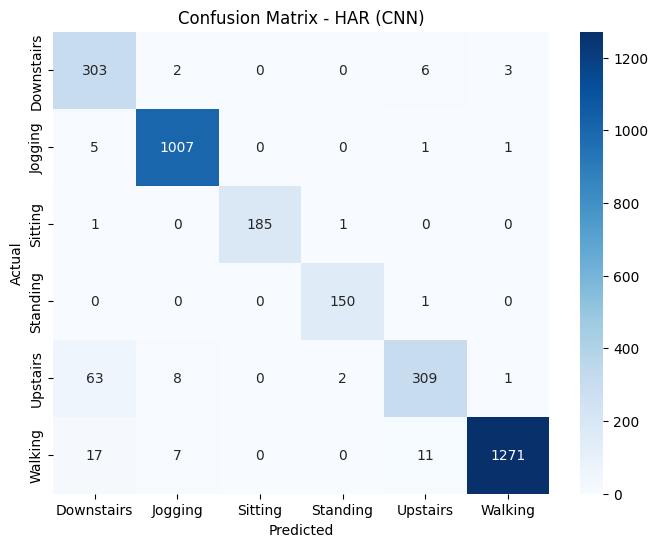

In [ ]:
y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - HAR (CNN)")
plt.show()
